# 6001CMD Machine Learning – Telco Customer Churn Analysis

**Dataset:** Telco Customer Churn  
**Source:** Kaggle – https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
**Purpose:** This notebook provides the Python evidence for Tasks 1–4 of the 6001CMD Machine Learning assignment.

### Tasks covered
1. Machine Learning Problem Formulation
2. Comparative Analysis of Supervised and Unsupervised Learning
3. Critical Analysis of Data Quality
4. Data Preprocessing Strategy Evaluation

### Important
Run the notebook from top to bottom. The code is designed to generate the tables, graphs and model outputs used in the report. Small output screenshots can be placed in the main report, while full notebook screenshots can be placed in the appendix.


## 0. Import Libraries and Load Dataset

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, silhouette_score
)

RANDOM_STATE = 42

# The CSV is expected to be in the same project folder as the notebook,
# or in /mnt/data when running in ChatGPT.
possible_paths = [
    Path("WA_Fn-UseC_-Telco-Customer-Churn.csv"),
    Path("/mnt/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "CSV not found. Place WA_Fn-UseC_-Telco-Customer-Churn.csv "
        "in the notebook folder and run this cell again."
    )

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset loaded successfully.
Rows: 7043
Columns: 21


## Task 1 – Machine Learning Problem Formulation

### 1.1 Dataset Overview

In [2]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst five rows:")
display(df.head())


Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

First five rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.2 Target Variable

The target variable is `Churn`. It contains two classes: `Yes` and `No`, making the primary machine learning problem a **binary classification** task.


In [3]:
target_counts = df["Churn"].value_counts()
target_percent = df["Churn"].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
})

display(target_summary)


,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


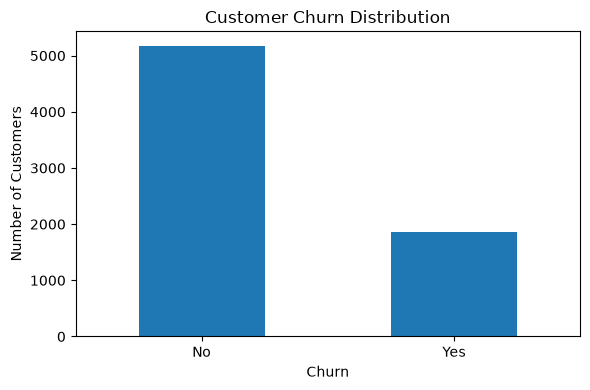

In [4]:
plt.figure(figsize=(6, 4))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 1.3 Feature Summary

In [5]:
feature_summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique(),
    "Missing Values": df.isna().sum()
})

display(feature_summary)


,Data Type,Unique Values,Missing Values
customerID,object,7043,0
gender,object,2,0
SeniorCitizen,int64,2,0
Partner,object,2,0
Dependents,object,2,0
tenure,int64,73,0
PhoneService,object,2,0
MultipleLines,object,3,0
InternetService,object,3,0
OnlineSecurity,object,3,0


## Task 2 – Comparative Analysis of Learning Paradigms

The notebook demonstrates both approaches:

- **Supervised learning:** predicts the known `Churn` label.
- **Unsupervised learning:** uses K-Means to group customers without using `Churn`.


### 2.1 Prepare a Clean Modelling Dataset

In [6]:
# Convert TotalCharges from text to numeric.
df_model = df.copy()
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce")

# Remove the identifier because customerID is not a meaningful predictive feature.
df_model = df_model.drop(columns=["customerID"])

print("Shape after removing customerID:", df_model.shape)
print("Missing TotalCharges:", df_model["TotalCharges"].isna().sum())


Shape after removing customerID: (7043, 20)
Missing TotalCharges: 11


### 2.2 Supervised Learning – Train/Test Split and Preprocessing

In [7]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Training records: 5634
Testing records: 1409
Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 2.3 Supervised Models

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    fitted_models[name] = pipe

model_results = pd.DataFrame(results).sort_values("F1", ascending=False)
display(model_results.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8420
2,Random Forest,0.8055,0.6701,0.5267,0.5898,0.8433
1,Decision Tree,0.7970,0.6746,0.4545,0.5431,0.8278


### 2.4 Confusion Matrix for the Selected Demonstration Model

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



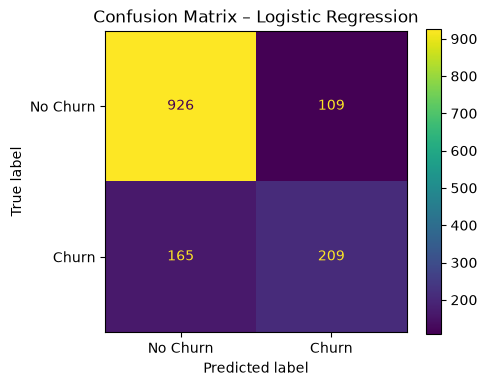

In [9]:
# Use Logistic Regression as the transparent baseline demonstration.
selected_model_name = "Logistic Regression"
selected_model = fitted_models[selected_model_name]

y_pred_selected = selected_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_selected,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred_selected)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot(ax=ax, values_format="d")
ax.set_title(f"Confusion Matrix – {selected_model_name}")
plt.tight_layout()
plt.show()


### 2.5 Unsupervised Learning – K-Means

K-Means does not use `Churn` during clustering. It groups customers according to their numerical representation.

For this demonstration, the numerical customer features are scaled before clustering. The categorical variables are excluded from this simple demonstration so that the clustering distance calculation remains straightforward; this should be acknowledged as a limitation in the report.


In [10]:
cluster_features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

cluster_data = df_model[cluster_features].copy()

cluster_data = cluster_data.fillna(cluster_data.median())

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_data)

cluster_results = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(cluster_scaled)
    score = silhouette_score(cluster_scaled, labels)
    cluster_results.append({"k": k, "Silhouette Score": score})

cluster_scores = pd.DataFrame(cluster_results)
display(cluster_scores.round(4))


,k,Silhouette Score
0,2,0.4041
1,3,0.4613
2,4,0.4279
3,5,0.4471
4,6,0.4704


In [11]:
best_k = int(
    cluster_scores.loc[
        cluster_scores["Silhouette Score"].idxmax(), "k"
    ]
)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans.fit_predict(cluster_scaled)

df_clustered = df_model.copy()
df_clustered["CustomerCluster"] = cluster_labels

print("Selected number of clusters:", best_k)
print("\nCustomers in each cluster:")
print(df_clustered["CustomerCluster"].value_counts().sort_index())


Selected number of clusters: 6

Customers in each cluster:
CustomerCluster
0    1551
1    1788
2     683
3    1516
4    1046
5     459
Name: count, dtype: int64


In [12]:
cluster_profile = (
    df_clustered
    .groupby("CustomerCluster")[cluster_features]
    .mean()
    .round(2)
)

display(cluster_profile)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
CustomerCluster,,,,
0,0.0,10.08,31.05,292.12
1,0.0,15.49,79.40,1230.41
2,1.0,17.39,70.69,1126.51
3,0.0,59.89,92.26,5517.47
4,0.0,53.39,33.43,1755.31
5,1.0,56.97,93.41,5316.22


## Task 3 – Critical Analysis of Data Quality

### 3.1 Missing Values

In [13]:
missing_summary = (
    df.isna().sum()
    .sort_values(ascending=False)
    .to_frame("Missing Values")
)

missing_summary["Percentage"] = (
    missing_summary["Missing Values"] / len(df) * 100
).round(3)

# Original TotalCharges is text, so blank strings must also be checked.
blank_totalcharges = (df["TotalCharges"].astype(str).str.strip() == "").sum()

print("Blank TotalCharges values:", blank_totalcharges)
print("\nMissing values reported by pandas:")
display(missing_summary[missing_summary["Missing Values"] > 0])


Blank TotalCharges values: 11

Missing values reported by pandas:


,Missing Values,Percentage


In [14]:
df_quality = df.copy()
df_quality["TotalCharges_numeric"] = pd.to_numeric(
    df_quality["TotalCharges"],
    errors="coerce"
)

print(
    "Missing/invalid TotalCharges after numeric conversion:",
    df_quality["TotalCharges_numeric"].isna().sum()
)

print("\nTenure values for affected records:")
display(
    df_quality.loc[
        df_quality["TotalCharges_numeric"].isna(),
        ["tenure", "TotalCharges"]
    ]
)


Missing/invalid TotalCharges after numeric conversion: 11

Tenure values for affected records:


,tenure,TotalCharges
488,0,
753,0,
936,0,
1082,0,
1340,0,
3331,0,
3826,0,
4380,0,
5218,0,
6670,0,


### 3.2 Duplicate Records

In [15]:
duplicate_count = df.duplicated().sum()
print("Exact duplicate rows:", duplicate_count)


Exact duplicate rows: 0


### 3.3 Numerical Descriptive Statistics and Skewness

In [16]:
df_stats = df_quality[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges_numeric"]
].describe().T

df_stats["skewness"] = df_quality[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges_numeric"]
].skew()

display(df_stats.round(3))


,count,mean,std,min,25%,50%,75%,max,skewness
SeniorCitizen,7043.0,0.162,0.369,0.00,0.00,0.000,0.000,1.00,1.834
tenure,7043.0,32.371,24.559,0.00,9.00,29.000,55.000,72.00,0.240
MonthlyCharges,7043.0,64.762,30.090,18.25,35.50,70.350,89.850,118.75,-0.221
TotalCharges_numeric,7032.0,2283.300,2266.771,18.80,401.45,1397.475,3794.738,8684.80,0.962


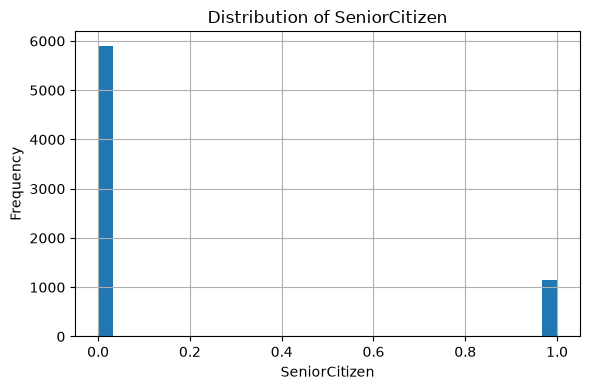

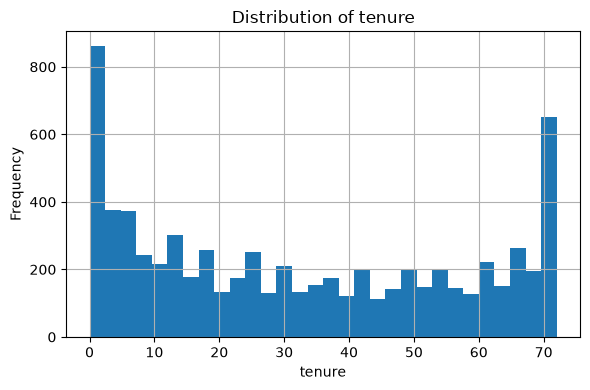

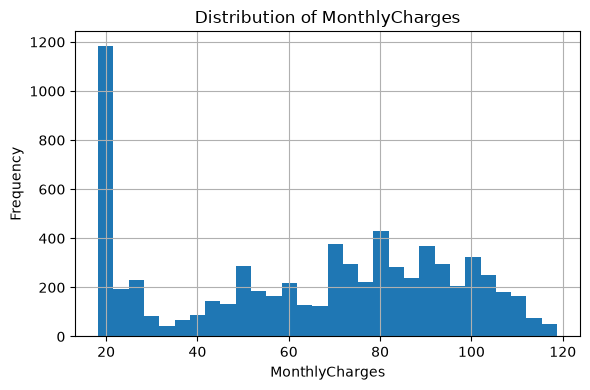

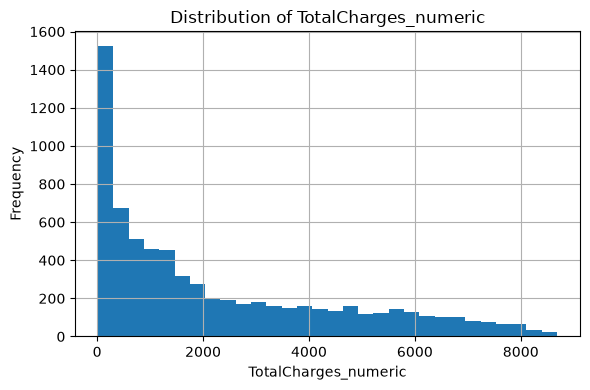

In [17]:
numerical_columns = [
    "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges_numeric"
]

for column in numerical_columns:
    plt.figure(figsize=(6, 4))
    df_quality[column].dropna().hist(bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


### 3.4 Outlier Analysis Using IQR

In [18]:
outlier_rows = []

for column in ["tenure", "MonthlyCharges", "TotalCharges_numeric"]:
    series = df_quality[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((series < lower) | (series > upper)).sum()

    outlier_rows.append({
        "Feature": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count
    })

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary.round(3))


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,tenure,9.00,55.000,46.000,-60.000,124.000,0
1,MonthlyCharges,35.50,89.850,54.350,-46.025,171.375,0
2,TotalCharges_numeric,401.45,3794.738,3393.288,-4688.481,8884.669,0


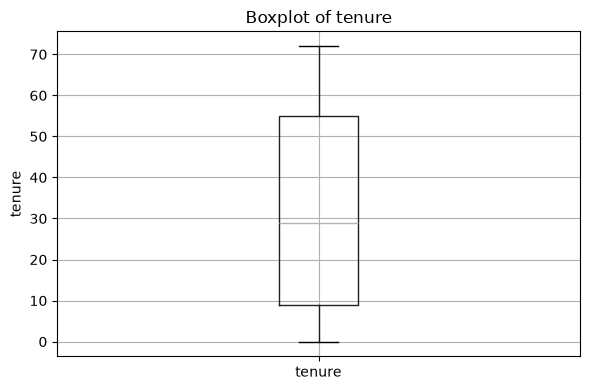

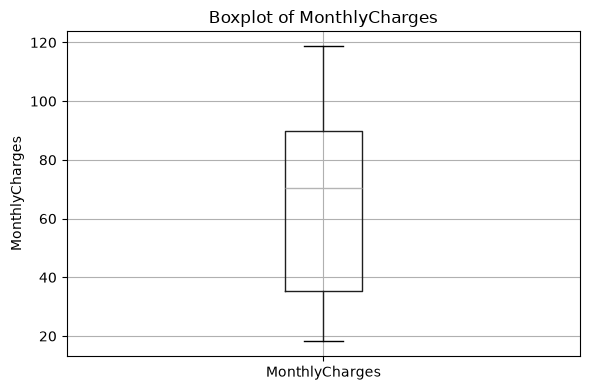

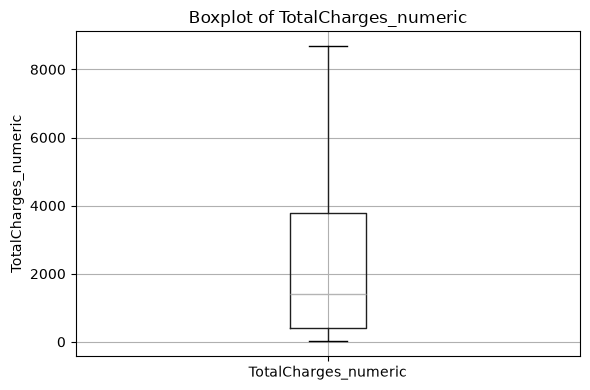

In [19]:
for column in ["tenure", "MonthlyCharges", "TotalCharges_numeric"]:
    plt.figure(figsize=(6, 4))
    df_quality.boxplot(column=column)
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()


### 3.5 Correlation Analysis

In [20]:
correlation_columns = [
    "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges_numeric"
]

corr_matrix = df_quality[correlation_columns].corr()

display(corr_matrix.round(3))


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges_numeric
SeniorCitizen,1.000,0.017,0.220,0.102
tenure,0.017,1.000,0.248,0.826
MonthlyCharges,0.220,0.248,1.000,0.651
TotalCharges_numeric,0.102,0.826,0.651,1.000


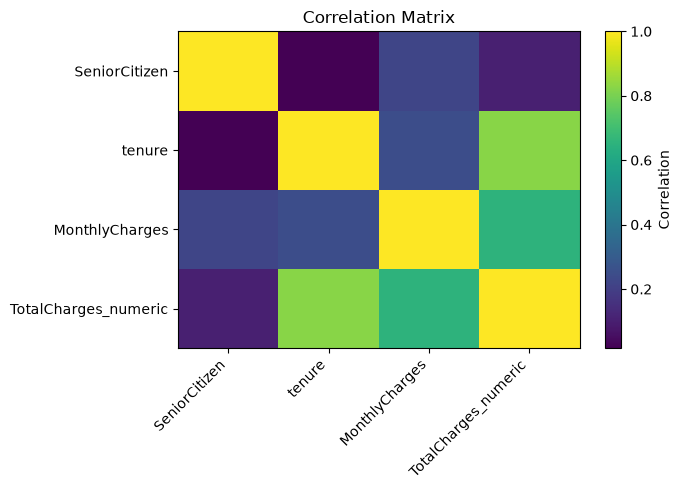

In [21]:
plt.figure(figsize=(7, 5))
plt.imshow(corr_matrix, interpolation="nearest", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_columns)), correlation_columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


### 3.6 Categorical Value Checks

In [22]:
categorical_columns_original = df.select_dtypes(include="object").columns

for column in categorical_columns_original:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(10))



customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
9305-CDSKC    1
1452-KIOVK    1
6713-OKOMC    1
7892-POOKP    1
6388-TABGU    1
Name: count, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Na

## Task 4 – Data Preprocessing Strategy Evaluation

### 4.1 Preprocessing Decisions

In [23]:
# Convert TotalCharges to numeric and remove identifier.
df_preprocessed = df.copy()
df_preprocessed["TotalCharges"] = pd.to_numeric(
    df_preprocessed["TotalCharges"],
    errors="coerce"
)
df_preprocessed = df_preprocessed.drop(columns=["customerID"])

print("Shape after removing customerID:", df_preprocessed.shape)
print("Missing TotalCharges:", df_preprocessed["TotalCharges"].isna().sum())


Shape after removing customerID: (7043, 20)
Missing TotalCharges: 11


### 4.2 Compare TotalCharges Before and After Log Transformation

Original skewness: 0.9616
Log-transformed skewness: -0.7431


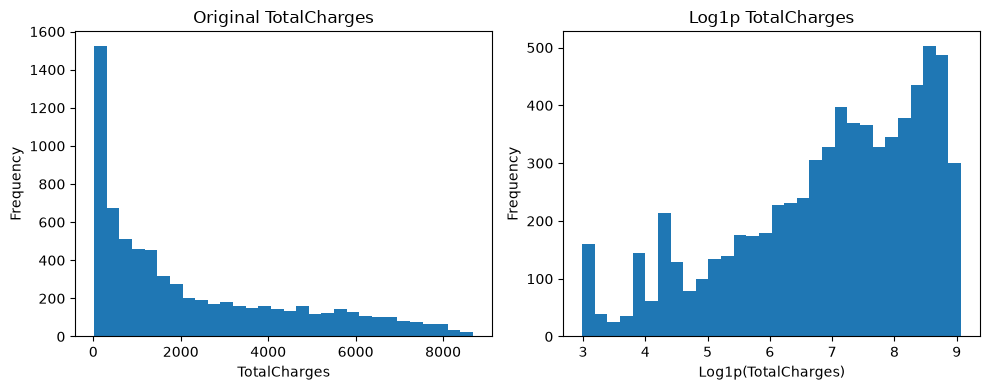

In [24]:
tc = df_preprocessed["TotalCharges"]

print("Original skewness:", round(tc.skew(), 4))

# log1p requires non-negative values; TotalCharges is non-negative in this dataset.
tc_log = np.log1p(tc)
print("Log-transformed skewness:", round(tc_log.skew(), 4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(tc.dropna(), bins=30)
axes[0].set_title("Original TotalCharges")
axes[0].set_xlabel("TotalCharges")
axes[0].set_ylabel("Frequency")

axes[1].hist(tc_log.dropna(), bins=30)
axes[1].set_title("Log1p TotalCharges")
axes[1].set_xlabel("Log1p(TotalCharges)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


### 4.3 One-Hot Encoding and Standardisation Pipeline

In [25]:
X = df_preprocessed.drop(columns=["Churn"])
y = df_preprocessed["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 4.4 SMOTE Evaluation

In [26]:
# Demonstrate SMOTE if imbalanced-learn is available.
# SMOTE is applied only to the training set.
try:
    from imblearn.over_sampling import SMOTE

    # Transform the training data first.
    X_train_transformed = preprocessor.fit_transform(X_train)

    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_smote, y_train_smote = smote.fit_resample(
        X_train_transformed,
        y_train
    )

    print("Before SMOTE:")
    print(y_train.value_counts())

    print("\nAfter SMOTE:")
    print(pd.Series(y_train_smote).value_counts())

except ImportError:
    print("imbalanced-learn is not installed.")
    print("Install it with: pip install imbalanced-learn")


Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


### 4.5 SMOTE Model Comparison (Optional but Recommended)

In [27]:
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE

    smote_model = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])

    smote_model.fit(X_train, y_train)
    smote_pred = smote_model.predict(X_test)
    smote_prob = smote_model.predict_proba(X_test)[:, 1]

    smote_results = pd.DataFrame([{
        "Model": "Logistic Regression + SMOTE",
        "Accuracy": accuracy_score(y_test, smote_pred),
        "Precision": precision_score(y_test, smote_pred, zero_division=0),
        "Recall": recall_score(y_test, smote_pred, zero_division=0),
        "F1": f1_score(y_test, smote_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, smote_prob)
    }])

    display(smote_results.round(4))

except ImportError:
    print("imbalanced-learn is not installed, so the SMOTE model comparison was skipped.")


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression + SMOTE,0.7374,0.5034,0.7995,0.6178,0.8402


## 5. Export Key Results

The following cells save important results so that they can be used in the report and appendix.


In [28]:
OUTPUT_DIR = Path("telco_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

target_summary.to_csv(OUTPUT_DIR / "target_distribution.csv")
feature_summary.to_csv(OUTPUT_DIR / "feature_summary.csv")
df_stats.to_csv(OUTPUT_DIR / "numerical_statistics.csv")
outlier_summary.to_csv(OUTPUT_DIR / "outlier_analysis.csv")
corr_matrix.to_csv(OUTPUT_DIR / "correlation_matrix.csv")
model_results.to_csv(OUTPUT_DIR / "model_results.csv", index=False)
cluster_scores.to_csv(OUTPUT_DIR / "cluster_scores.csv", index=False)
cluster_profile.to_csv(OUTPUT_DIR / "cluster_profile.csv")

print("Results exported to:", OUTPUT_DIR.resolve())


Results exported to: C:\xampp\htdocs\telco_outputs
